In [1]:
import pandas as pd
from matplotlib import pyplot as plt

df_features = pd.read_parquet("../data/processed/dimuon_anomaly_results.parquet")

df_features.head()

,pt1,eta1,phi1,E1,Q1,pt2,eta2,phi2,E2,Q2,M,anomaly_score,anomaly_label
0,4.2116,2.2366,-0.4849,19.9382,1,1.2556,2.2683,-1.4488,6.1319,-1,2.1330,0.168426,1
1,2.1479,-2.0159,-2.7753,8.2066,-1,19.5453,-1.0826,-0.3408,32.1613,1,13.6786,0.108845,1
2,21.0732,1.5948,-1.1137,54.0560,1,2.3864,1.5352,-1.7388,5.7968,-1,4.3813,0.170665,1
3,18.5889,1.6422,1.1923,49.8180,1,1.8721,1.9704,1.6393,6.8459,-1,3.2587,0.165416,1
4,11.8194,0.8711,-1.5811,16.5947,-1,0.9408,2.0107,-1.6559,3.5779,1,4.0171,0.171313,1


In [2]:
normal = df_features[df_features["anomaly_label"] == 1]
anomaly = df_features[df_features["anomaly_label"] == -1]

len(normal), len(anomaly)

(82085, 1676)

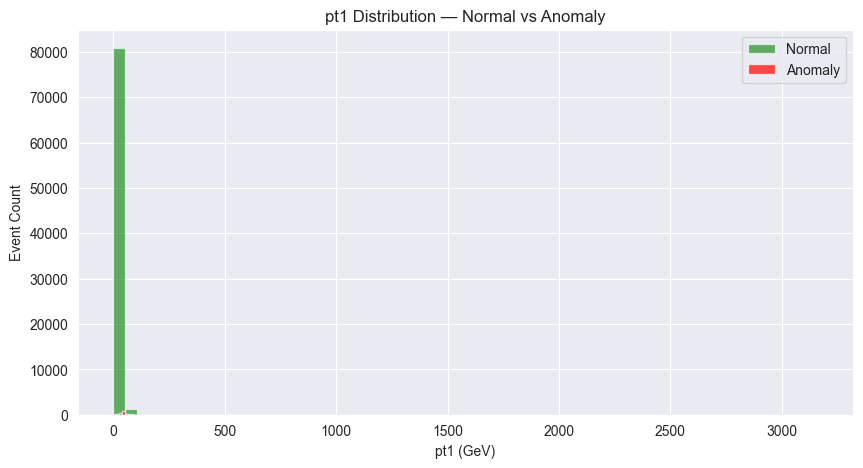

In [3]:
plt.figure(figsize=(10,5))
plt.hist(normal["pt1"], bins=60, alpha=0.6, label= "Normal", color="green")
plt.hist(anomaly["pt1"], bins=60, alpha=0.7, label= "Anomaly", color="red")
plt.xlabel("pt1 (GeV)")
plt.ylabel("Event Count")
plt.title("pt1 Distribution — Normal vs Anomaly")
plt.legend()
plt.show()

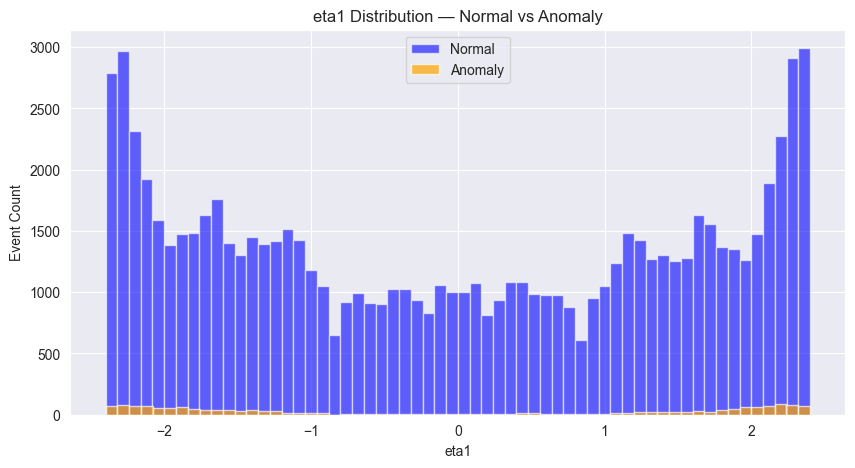

In [4]:
plt.figure(figsize=(10,5))
plt.hist(normal["eta1"], bins=60, alpha=0.6, label="Normal", color="blue")
plt.hist(anomaly["eta1"], bins=60, alpha=0.7, label="Anomaly", color="orange")
plt.xlabel("eta1")
plt.ylabel("Event Count")
plt.title("eta1 Distribution — Normal vs Anomaly")
plt.legend()
plt.show()

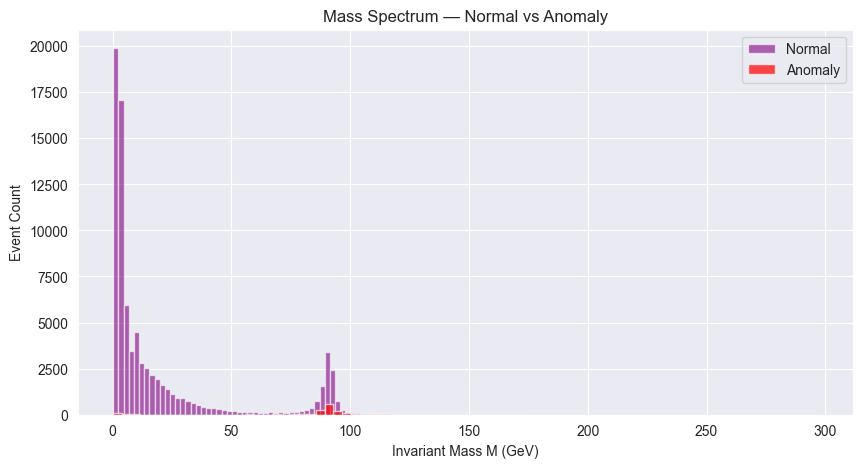

In [5]:
plt.figure(figsize=(10,5))
plt.hist(normal["M"], bins=80, alpha=0.6, label="Normal", color="purple")
plt.hist(anomaly["M"], bins=80, alpha=0.7, label="Anomaly", color="red")
plt.xlabel("Invariant Mass M (GeV)")
plt.ylabel("Event Count")
plt.title("Mass Spectrum — Normal vs Anomaly")
plt.legend()
plt.show()

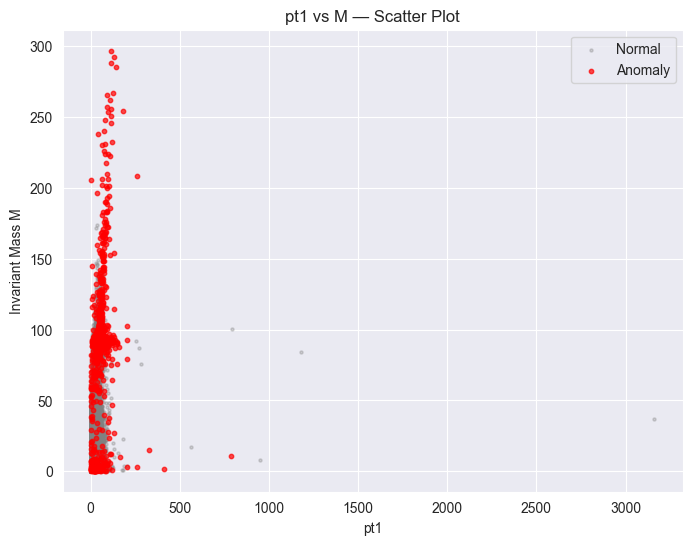

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(normal["pt1"], normal["M"], s=5, alpha=0.3, label="Normal", color="gray")
plt.scatter(anomaly["pt1"], anomaly["M"], s=10, alpha=0.7, label="Anomaly", color="red")
plt.xlabel("pt1")
plt.ylabel("Invariant Mass M")
plt.title("pt1 vs M — Scatter Plot")
plt.legend()
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_cols = ["pt1","eta1","phi1","E1","Q1",
                "pt2","eta2","phi2","E2","Q2","M"]

X = df_features[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df_features["pca1"] = pca_result[:,0]
df_features["pca2"] = pca_result[:,1]

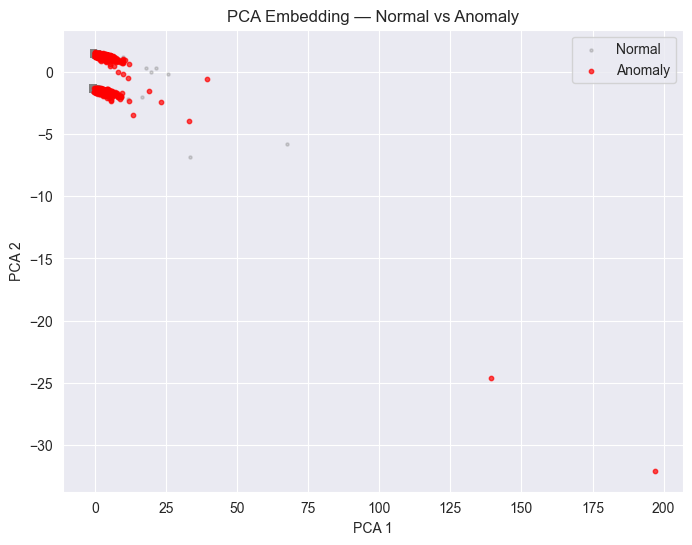

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(df_features[df_features["anomaly_label"]==1]["pca1"],
            df_features[df_features["anomaly_label"]==1]["pca2"],
            s=5, alpha=0.3, label="Normal", color="gray")

plt.scatter(df_features[df_features["anomaly_label"]==-1]["pca1"],
            df_features[df_features["anomaly_label"]==-1]["pca2"],
            s=10, alpha=0.7, label="Anomaly", color="red")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Embedding — Normal vs Anomaly")
plt.legend()
plt.show()